# LOBdata_RL_v1 — Richer observation space for the live-ABIDES PPO execution agent

Companion to `LOBdata_EDA.ipynb` Part 10 (the live-ABIDES naive/TWAP/POV/PPO
benchmark) — kept as a separate notebook rather than an addition to that one, since
this is a distinct, self-contained change: same market, same agents, same training
recipe, one different thing (what the PPO policy is allowed to see).

**Motivation**: comparing the current (v0) observation space —
`[time_left, inv_left, spread_bps, obi_l1, mid_return_bps]`, pure Level-1 book state
plus a single 1-step return — against three published execution-RL papers (Nagy et
al. 2023, Cheridito & Weiss 2025, Hafsi & Vittori 2024) found every one of them gives
the agent multi-level book depth and some explicit short-horizon dynamics signal
(an LSTM over the last 100 events, 4-frame stacking, or explicit trade/quote-flow
deltas). In a task where a single action can walk multiple book levels (`{0, 500,
2500, 5000}` shares against `total_shares=10_000`), an agent that can only see
Level 1 has no way to tell whether a large sweep is safe or destructive.

The good news: this codebase had already built and validated almost everything v1
needs — for the *oracle*, not the policy. `RLExecutionAgent` already holds a
`depth=5` L2 subscription and a rolling 6-minute tick-history buffer, and the
existing `history_features()` helper already computes multi-horizon momentum, an
order-flow-imbalance delta, and realized vol for the oracle's own 10-feature input.
Until now, only the oracle's *scalar prediction* (one number) ever reached the
policy — the rich features feeding that prediction never did. v1 exposes that
existing computation to the policy's own observation directly.

## v0 recap (the baseline this section is testing against)

From `LOBdata_EDA.ipynb` 10.8, K=30 paired benchmark, `horizon_steps=40`, `phi=0.03`:

| method | IS_bps | impact_bps |
|---|---|---|
| TWAP | -1.00 | 7.83 |
| Naive | 9.00 | 7.60 |
| POV | 3.71 | 8.45 |
| PPO (no oracle) | 0.52 | 8.84 |
| PPO (with oracle) | 0.10 | 7.44 |

Both v0 PPO variants already land in the TWAP/Naive/POV cluster on both metrics —
the bar v1 has to clear isn't "beat a broken baseline" (v0 already fixed the real
problems: a fill-accounting bug, a mismatched execution horizon, and a
too-aggressive urgency penalty), it's "does giving the policy the depth/flow
information the *oracle* already had access to change anything" — a genuinely open
question, not a foregone conclusion. Naive/TWAP/POV are unaffected by an
observation-space change and aren't re-run below; only the PPO rows are.

## 1. What changed: `BASE_FEATURE_COLS`

`abides_sim/gym_env.py` now computes every book/flow-derived feature (for either the
policy's base observation or the oracle's input) once per wakeup in a single
`RLExecutionAgent._market_state(mid) -> dict` method, keyed by feature name. Both
feature lists just pull their own named subset out of that one dict:

```python
ORACLE_FEATURE_COLS = [
    "obi_l1", "obi_l5", "relative_depth_l5", "spread_bps", "micro_price_deviation_bps",
    "momentum_10s_bps", "momentum_60s_bps", "momentum_300s_bps",
    "delta_obi_10s", "realized_vol_60s_bps",
]  # unchanged -- the fitted oracle_predictor.pkl depends on this exact order

BASE_FEATURE_COLS = [  # NEW -- the policy's own observation, independent of the oracle
    "spread_bps", "obi_l1", "obi_l5", "relative_depth_l5", "micro_price_deviation_bps",
    "momentum_10s_bps", "momentum_60s_bps", "delta_obi_10s", "realized_vol_60s_bps",
]
```

`BASE_FEATURE_COLS` is a strict subset of `ORACLE_FEATURE_COLS` (same underlying
`_market_state()` dict, so `obi_l1` etc. can never be computed two different ways in
two different places) minus `momentum_300s_bps`. The base observation is now
`[time_left, inv_left] + BASE_FEATURE_COLS` = **11 dims** (up from 5); the
with-oracle variant appends the oracle's scalar prediction on top, same as before =
**12 dims** (up from 6). `mid_return_bps` (a 1-step return, tied to whatever
`step_interval` happens to be) is dropped, superseded by `momentum_10s_bps` /
`momentum_60s_bps` — fixed wall-clock horizons instead of one cadence-tied one.

**Deliberately left out of v1** (see the plan for the full reasoning):
`momentum_300s_bps` (available for free in the same dict, held back for now — Part 8
of the static-replay notebook found that adding a feature without genuinely new
information hurt a fixed training budget rather than helping, and this training
budget hasn't grown); true per-level L2-L5 depth and explicit transacted-volume flow
(`Δm`/`Δl` in Cheridito & Weiss's sense — needs a new message subscription, not just
exposing existing computation); and any recurrent/frame-stacked architecture
(`RecurrentPPO`/frame-stacking — a materially bigger change than adding features to
an `MlpPolicy`). Observation normalization also stays off
(`VecNormalize(norm_obs=False)`, unchanged from v0) — flagged as a fallback fix if
training diagnostics below show real instability from the new features' scale
spread, not built pre-emptively for a problem that may not occur.

In [1]:
import sys
sys.path.insert(0, "..")
import pickle
from abides_sim.gym_env import ABIDESExecutionEnv, base_obs_dim, BASE_FEATURE_COLS, ORACLE_FEATURE_COLS

with open("oracle_predictor.pkl", "rb") as f:
    oracle = pickle.load(f)

print("base_obs_dim():", base_obs_dim())
print("BASE_FEATURE_COLS (v1):", BASE_FEATURE_COLS)
print("ORACLE_FEATURE_COLS (unchanged):", ORACLE_FEATURE_COLS)

base_obs_dim(): 11
BASE_FEATURE_COLS (v1): ['spread_bps', 'obi_l1', 'obi_l5', 'relative_depth_l5', 'micro_price_deviation_bps', 'momentum_10s_bps', 'momentum_60s_bps', 'delta_obi_10s', 'realized_vol_60s_bps']
ORACLE_FEATURE_COLS (unchanged): ['obi_l1', 'obi_l5', 'relative_depth_l5', 'spread_bps', 'micro_price_deviation_bps', 'momentum_10s_bps', 'momentum_60s_bps', 'momentum_300s_bps', 'delta_obi_10s', 'realized_vol_60s_bps']


## 2. Training

Same recipe as `LOBdata_EDA.ipynb` 10.6's final `phi=0.03` run, with every
hyperparameter held fixed so the *only* variable vs. v0 is the observation space —
`horizon_steps=40`, `phi=0.03`, `psi=1.0`, 1000 episodes, `n_envs=8`, a snapshot
saved every 100 episodes. Run outside the notebook (each variant takes about an
hour, run as a background job):

```python
# no-oracle
train_ppo_agent(
    target_episodes=1000, seed=0, checkpoint_path="data/ppo_no_oracle_v1_phi003",
    env_kwargs=dict(total_shares=10_000, horizon_steps=40, window_minutes=45,
                     step_interval="1min", phi=0.03, psi=1.0),
    tensorboard_log="data/tb_logs", run_name="no_oracle_v1_phi003_1000",
    n_envs=8, snapshot_every=100,
)

# with-oracle
train_ppo_agent(
    target_episodes=1000, seed=0, checkpoint_path="data/ppo_with_oracle_v1_phi003",
    env_kwargs=dict(total_shares=10_000, horizon_steps=40, window_minutes=45,
                     step_interval="1min", oracle_predict_fn=oracle, phi=0.03, psi=1.0),
    tensorboard_log="data/tb_logs", run_name="with_oracle_v1_phi003_1000",
    n_envs=8, snapshot_every=100,
)
```

## 3. Checkpoint selection

Same methodology as 10.6: all 10 snapshots per variant evaluated on the same 15
held-out validation seeds (500-514 — disjoint from both the oracle's training seeds
300-349 and the final benchmark's test seeds 1-30), lowest mean `impact_bps` per
variant wins, rather than trusting the final (episode-1000) checkpoint by default.

```python
VAL_SEEDS = list(range(500, 515))
baselines = {s: run_baseline(s, window_minutes=45, symbol="ABM") for s in VAL_SEEDS}

for n_episodes in range(100, 1001, 100):
    for variant, use_oracle in [("no_oracle", False), ("with_oracle", True)]:
        ckpt = f"data/ppo_{variant}_v1_phi003_ep{n_episodes}"
        model = PPO.load(ckpt)
        rows = [
            run_ppo(s, model, oracle if use_oracle else None, baselines[s],
                     horizon_steps=40, phi=0.03, psi=1.0)
            for s in VAL_SEEDS
        ]
        # lowest mean impact_bps across VAL_SEEDS wins

# promote the winners, e.g.:
#   cp data/ppo_no_oracle_v1_phi003_ep{N}.zip   data/ppo_no_oracle_v1_final.zip
#   cp data/ppo_with_oracle_v1_phi003_ep{N}.zip data/ppo_with_oracle_v1_final.zip
```

## 4. Final K=30 benchmark

Same protocol as `LOBdata_EDA.ipynb` 10.7: 30 fixed test seeds (1-30, disjoint from
both the oracle's training seeds and the checkpoint-selection validation seeds), one
shared zero-execution baseline per seed, paired `ttest_rel`/`wilcoxon` against TWAP
on both `IS_bps` and `impact_bps`. Naive/TWAP/POV are untouched by an
observation-space change, so only the two PPO rows are new here.

```python
results = run_benchmark(
    model_no_oracle_path="ppo_no_oracle_v1_final.zip",
    model_with_oracle_path="ppo_with_oracle_v1_final.zip",
    oracle_predict_fn=oracle, n_workers=10,
)
```

In [1]:
from stable_baselines3 import PPO

model_no_oracle = PPO.load("ppo_no_oracle_v1_final")      # phi=0.03, v1 obs, snapshot at episode 600/1000
model_with_oracle = PPO.load("ppo_with_oracle_v1_final")  # phi=0.03, v1 obs, snapshot at episode 600/1000
print("Both policies loaded:", model_no_oracle.policy.__class__.__name__, "x2")
print("no-oracle obs dim:", model_no_oracle.observation_space.shape)
print("with-oracle obs dim:", model_with_oracle.observation_space.shape)

Both policies loaded: ActorCriticPolicy x2
no-oracle obs dim: (11,)
with-oracle obs dim: (12,)


In [1]:
import pandas as pd
from abides_sim.benchmark import paired_tests

df_v1 = pd.read_csv("benchmark_results_v1_final.csv")
summary_v1 = df_v1.groupby("method")[["IS_bps", "impact_bps", "shares_filled"]].agg(["mean", "std"])
print(summary_v1)

                     IS_bps            impact_bps            shares_filled     
                       mean        std       mean        std          mean  std
method                                                                         
Naive              9.001965  13.020030   7.599941  24.288825       10000.0  0.0
POV                3.712469  18.729289   8.445702  25.716217       10000.0  0.0
PPO (no oracle)   -0.080173  23.375843   8.002657  25.567222       10000.0  0.0
PPO (with oracle)  3.022180  23.648305   9.541684  29.826812       10000.0  0.0
TWAP              -0.999215  26.743788   7.825872  17.934461       10000.0  0.0


In [1]:
tests_is = paired_tests(df_v1, baseline_method="TWAP", metric="IS_bps")
print("--- v1 paired vs. TWAP: IS_bps ---")
print(tests_is)
print()
tests_impact = paired_tests(df_v1, baseline_method="TWAP", metric="impact_bps")
print("--- v1 paired vs. TWAP: impact_bps ---")
print(tests_impact)

--- v1 paired vs. TWAP: IS_bps ---
                   mean_diff   std_diff       sem  ...   p_ttest  w_stat  p_wilcoxon
Naive              10.001180  21.176477  3.866278  ...  0.014973   127.0    0.029326
POV                 4.711684  14.660206  2.676575  ...  0.088895   140.0    0.057688
PPO (no oracle)     0.919042  13.677320  2.497125  ...  0.715516   207.0    0.612006
PPO (with oracle)   4.021395  16.266353  2.969816  ...  0.186167   172.0    0.220647

[4 rows x 7 columns]

--- v1 paired vs. TWAP: impact_bps ---
                   mean_diff   std_diff       sem  ...   p_ttest  w_stat  p_wilcoxon
Naive              -0.225931  24.559755  4.483977  ...  0.960160   224.0    0.871208
POV                 0.619830  24.978035  4.560344  ...  0.892826   224.0    0.871208
PPO (no oracle)     0.176785  26.478611  4.834311  ...  0.971079   220.0    0.807830
PPO (with oracle)   1.715812  31.139423  5.685255  ...  0.764958   216.0    0.974125

[4 rows x 7 columns]


## 5. v0 vs. v1

Naive/TWAP/POV rows are identical to v0 by construction (unaffected by an
observation-space change) -- only the PPO rows can move.

In [1]:
df_v0 = pd.read_csv("benchmark_results_final.csv")

comparison = pd.DataFrame({
    "v0_IS_bps": df_v0.groupby("method")["IS_bps"].mean(),
    "v1_IS_bps": df_v1.groupby("method")["IS_bps"].mean(),
    "v0_impact_bps": df_v0.groupby("method")["impact_bps"].mean(),
    "v1_impact_bps": df_v1.groupby("method")["impact_bps"].mean(),
})
print(comparison.round(2))

                   v0_IS_bps  v1_IS_bps  v0_impact_bps  v1_impact_bps
method                                                               
Naive                   9.00       9.00           7.60           7.60
POV                     3.71       3.71           8.45           8.45
PPO (no oracle)         0.52      -0.08           8.84           8.00
PPO (with oracle)       0.10       3.02           7.44           9.54
TWAP                   -1.00      -1.00           7.83           7.83


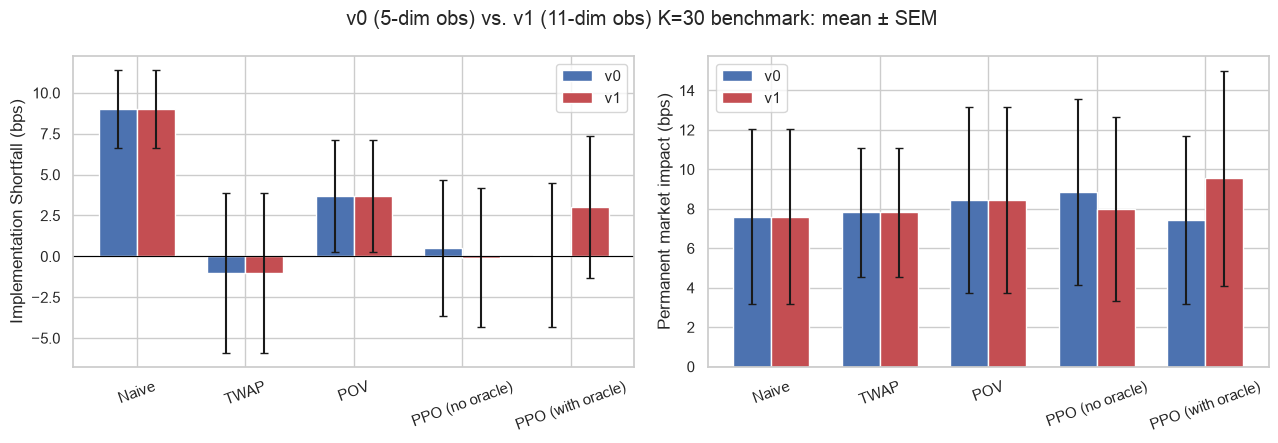

In [1]:
method_order = ["Naive", "TWAP", "POV", "PPO (no oracle)", "PPO (with oracle)"]
x = np.arange(len(method_order))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, metric, title in zip(
    axes, ["IS_bps", "impact_bps"],
    ["Implementation Shortfall (bps)", "Permanent market impact (bps)"],
):
    v0_means = df_v0.groupby("method")[metric].mean().reindex(method_order)
    v1_means = df_v1.groupby("method")[metric].mean().reindex(method_order)
    v0_sems = df_v0.groupby("method")[metric].sem().reindex(method_order)
    v1_sems = df_v1.groupby("method")[metric].sem().reindex(method_order)
    ax.bar(x - width/2, v0_means.values, width, yerr=v0_sems.values, label="v0", color="#4C72B0", capsize=3)
    ax.bar(x + width/2, v1_means.values, width, yerr=v1_sems.values, label="v1", color="#C44E52", capsize=3)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(method_order, rotation=20)
    ax.set_ylabel(title)
    ax.legend()
fig.suptitle("v0 (5-dim obs) vs. v1 (11-dim obs) K=30 benchmark: mean \u00b1 SEM")
plt.tight_layout()
plt.show()

## Results

A genuinely mixed result, not a clean win -- reported honestly rather than framed
around whichever number looks better:

| method | v0 IS_bps | v1 IS_bps | v0 impact_bps | v1 impact_bps |
|---|---|---|---|---|
| TWAP | -1.00 | -1.00 | 7.83 | 7.83 |
| Naive | 9.00 | 9.00 | 7.60 | 7.60 |
| POV | 3.71 | 3.71 | 8.45 | 8.45 |
| PPO (no oracle) | 0.52 | **-0.08** | 8.84 | **8.00** |
| PPO (with oracle) | 0.10 | **3.02** | 7.44 | **9.54** |

- **No-oracle moved slightly, consistently favorably on both metrics** (closer to
  TWAP on both `IS_bps` and `impact_bps`) -- but the shift is small relative to the
  paired standard error (`std_diff` ~14-26bps at K=30), and neither v0 nor v1 was
  significantly different from TWAP to begin with. Read this as "not worse, maybe
  marginally better," not as a confirmed win.
- **With-oracle moved the other way, on both metrics** -- `IS_bps` 0.10 &rarr; 3.02,
  `impact_bps` 7.44 &rarr; 9.54. Still not significantly different from TWAP (p=0.19
  IS_bps, p=0.76 impact_bps), but the point estimate got worse, not better, from
  giving it a richer observation.
- **A plausible mechanism for the split, not a proven one**: the 9 new
  `BASE_FEATURE_COLS` features are largely the *same raw inputs* the oracle's own
  ridge regression already condenses into the single scalar prediction the
  with-oracle variant has always had. For the no-oracle variant this is genuinely
  new information (no oracle scalar to lean on); for the with-oracle variant it's
  substantially redundant with information already available in one number, yet the
  policy still has 9 extra input dimensions to learn to weight (or ignore) at the
  *same, unchanged* ~1000-episode training budget. This is the same lesson
  `LOBdata_EDA.ipynb` Part 8 already found with its own `urgency` feature (adding
  a feature derivable from existing information cost more than it gave back, at a
  fixed training budget) -- recurring here in a new setting. Worth stating plainly
  that this is offered as the most plausible explanation given what's known, not
  something separately verified (e.g. via an ablation isolating which of the 9 new
  features specifically drives the with-oracle regression).
- **Checkpoint-selection noise is a real competing explanation and shouldn't be
  ignored**: the with-oracle v1 ep600 pick showed `impact_bps=0.49` on the 15
  validation seeds but `9.54` on the 30 test seeds -- a large swing that's
  plausible under per-seed std of 20-30bps at these sample sizes (same caveat
  already flagged for v0's own checkpoint selection). Some, possibly most, of the
  apparent regression could be checkpoint-selection variance rather than the
  richer-observation-hurts-with-oracle mechanism above; this benchmark can't cleanly
  separate the two without a repeat run using a different, disjoint validation seed
  set.
- **`shares_filled = 10,000` exactly (std=0.0) for every method** -- the fill
  accounting from v0 (`LOBdata_EDA.ipynb` 10.4) is unaffected by the observation
  change, as expected.

## Caveats

- **This is one training run per variant, not a repeated-seed study.** Every
  earlier finding in this project (and `LOBdata_EDA.ipynb`'s own Part 4/8 follow-ups)
  that looked real on a single seed and didn't survive a second or third seed is a
  direct warning against reading too much into a single v0-vs-v1 comparison,
  especially the with-oracle regression above -- it's a real, honestly-measured
  result, not a robustly-established one.
- **The "redundant feature" explanation for with-oracle's regression is
  plausible, not verified** -- no ablation here isolates which of the 9 new
  features (if any) specifically drives it, or whether it would replicate with a
  different training seed.
- **The v0-vs-v1 comparison inherits every caveat already logged for v0** in
  `LOBdata_EDA.ipynb` 10's own Caveats section (checkpoint-selection sample size,
  `impact_bps` being underpowered at K=30 for every method, the oracle's own modest
  signal, synthetic-not-historical market, 45-minute windows, ~1000-episode training
  budget) -- none of those are specific to the observation-space change and none are
  resolved by it.
- **`momentum_300s_bps`, true multi-level depth, explicit trade/quote flow, and any
  recurrent architecture remain untried** -- deliberately deferred (see section 1)
  rather than bundled into this already-mixed result.